# 04. Contrastes Estadisticos, Explicabilidad XAI (SHAP / Fed SR 11-7), Curvas de Lift y Stress Testing Monte Carlo

In [1]:
# Modulo de referencia: Entregable/src/explainability/shap_explainer.py
# Referencia modular: Los procesos de explicabilidad y contrastes se encuentran desacoplados en src/
# Modulos: src/explainability/shap_explainer.py, src/evaluation/statistical_tests.py, src/evaluation/stress_testing.py, src/evaluation/drift_monitor.py
# Inicializacion del entorno, rutas relativas y semillas deterministas
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')

# Resolucion determinista de la raiz del proyecto
ROOT_DIR = Path.cwd().resolve()
if ROOT_DIR.name == 'notebooks':
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

DATA_DIR = ROOT_DIR / 'data' / 'processed' / 'sec_dataset'
if not DATA_DIR.exists() and (ROOT_DIR / 'Entregable' / 'data' / 'processed' / 'sec_dataset').exists():
    DATA_DIR = ROOT_DIR / 'Entregable' / 'data' / 'processed' / 'sec_dataset'
elif not DATA_DIR.exists() and (ROOT_DIR.parent / 'data' / 'processed' / 'sec_dataset').exists():
    DATA_DIR = ROOT_DIR.parent / 'data' / 'processed' / 'sec_dataset'

FIGURES_DIR = ROOT_DIR / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fijacion de semillas deterministas
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuracion sobria de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 11
plt.rcParams['figure.titleweight'] = 'bold'

print(f'Directorio raiz: {ROOT_DIR}')
print(f'Directorio de datos: {DATA_DIR} (Existe: {DATA_DIR.exists()})')
print(f'Directorio de figuras: {FIGURES_DIR} (Existe: {FIGURES_DIR.exists()})')

Directorio raiz: E:\TFM data science\Entregable
Directorio de datos: E:\TFM data science\Entregable\data\processed\sec_dataset (Existe: True)
Directorio de figuras: E:\TFM data science\Entregable\reports\figures (Existe: True)


## 1. Contrastes Estadisticos Formales y Pruebas de Hipotesis

En esta seccion se recogen las pruebas de hipotesis estadisticas formales para evaluar de forma no parametrica la superioridad discriminante de los modelos:
- Test de DeLong pareado para comparacion de areas bajo la curva ROC (ROC-AUC) Contrasta si la diferencia entre las áreas bajo la curva ROC de dos modelos es estadísticamente significativa o fruto del azar. Al evaluar ambos algoritmos sobre las mismas empresas (muestras dependientes), tiene en cuenta la correlación entre sus predicciones mediante U-estadísticos, sin necesidad de asumir distribuciones normales.
- Test de McNemar Evalúa si dos modelos cometen una proporción significativamente distinta de errores binarios tras aplicar el umbral óptimo. Se centra de forma estricta en los casos discordantes (aquellas observaciones donde un modelo acierta y el otro falla), verificando si los aciertos exclusivos del modelo líder son sistemáticos o meramente aleatorios.
- Estimacion de intervalos de confianza empiricos al 95% mediante remuestreo Bootstrap con B = 1,000 replicas para PR-AUC y ROC-AUC.

In [2]:
# Modulo de referencia: Entregable/src/evaluation/statistical_tests.py
# Contrastes estadisticos formales y pruebas de hipotesis sobre la particion de validacion fuera de muestra (2022-2026, 108,994 obs.)
from IPython.display import display, Markdown
import pandas as pd

# Carga dinamica de los resultados de contrastes estadisticos generados empiricamente
delong_csv = ROOT_DIR / 'data' / 'processed' / 'sec_dataset' / 'delong_tests_results.csv'
mcnemar_csv = ROOT_DIR / 'data' / 'processed' / 'sec_dataset' / 'mcnemar_tests_results.csv'
bootstrap_csv = ROOT_DIR / 'data' / 'processed' / 'sec_dataset' / 'bootstrap_ci_results.csv'

delong_results_df = pd.read_csv(delong_csv) if delong_csv.exists() else pd.DataFrame()
mcnemar_results_df = pd.read_csv(mcnemar_csv) if mcnemar_csv.exists() else pd.DataFrame()
bootstrap_results_df = pd.read_csv(bootstrap_csv) if bootstrap_csv.exists() else pd.DataFrame()

# Lectura e integracion directa del informe oficial de contrastes estadisticos (Anexo E)
anexo_e_file = ROOT_DIR / 'anexos' / 'Anexo_E_Contrastes_Estadisticos.md'
if anexo_e_file.exists():
    with open(anexo_e_file, 'r', encoding='utf-8') as f:
        anexo_md = f.read()
    # Secciones E.1 (DeLong), E.2 (McNemar) y E.3 (Bootstrap CIs)
    statistical_tables_md = anexo_md.split('## E.4')[0].strip()
    statistical_tables_md = statistical_tables_md.replace('# Anexo E: Contrastes Estadísticos Formales y Evaluación de Significancia\n\n', '')
    display(Markdown(statistical_tables_md))
else:
    print('Reporte oficial de contrastes estadisticos no encontrado en anexos/Anexo_E_Contrastes_Estadisticos.md')
    if not delong_results_df.empty:
        display(delong_results_df)
    if not mcnemar_results_df.empty:
        display(mcnemar_results_df)
    if not bootstrap_results_df.empty:
        display(bootstrap_results_df)

En este anexo se recogen las pruebas de hipótesis estadísticas, contrastes no paramétricos de curvas ROC (DeLong), tablas de contingencia discordante (McNemar), intervalos de confianza empíricos mediante remuestreo Bootstrap ($B=1000$ réplicas) y pruebas de bondad de ajuste de Hosmer-Lemeshow para los modelos del TFM.

---

## E.1 Test de DeLong para Comparación de Curvas ROC-AUC

El test de DeLong et al. (1988) compara de forma no paramétrica las áreas bajo la curva ROC de modelos pareados sobre la misma cohorte de validación independiente:

| Comparación de Modelos | $\Delta \mathrm{AUC}$ | Estadístico $Z$ | $p\mathrm{-valor}$ | Significativo ($\alpha=0.05$) |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost (SOTA 12M) vs Altman & Merton** | **+0.0799** | **62.740** | **0.0000e+00** | **SÍ ($p < 0.001$)** |
| **XGBoost (SOTA 12M) vs Scorecard WOE** | **+0.0149** | **28.019** | **0.0000e+00** | **SÍ ($p < 0.001$)** |
| **XGBoost (SOTA 12M) vs LightGBM** | **+0.0001** | **0.374** | **0.7087** | **NO ($p > 0.001$)** |
| **XGBoost (SOTA 12M) vs CatBoost GPU** | **+0.0054** | **12.798** | **0.0000** | **SÍ ($p < 0.001$)** |
| **LightGBM vs Altman & Merton** | **+0.0798** | **63.615** | **0.0000e+00** | **SÍ ($p < 0.001$)** |
| **LightGBM vs Scorecard WOE** | **+0.0149** | **27.680** | **0.0000e+00** | **SÍ ($p < 0.001$)** |
| **CatBoost GPU vs Altman & Merton** | **+0.0745** | **64.191** | **0.0000e+00** | **SÍ ($p < 0.001$)** |
| **CatBoost GPU vs Scorecard WOE** | **+0.0095** | **15.320** | **0.0000e+00** | **SÍ ($p < 0.001$)** |

---

## E.2 Test de McNemar sobre Matrices de Confusión Discordantes

| Comparación | Casos $b$ ($M_1=1, M_2=0$) | Casos $c$ ($M_1=0, M_2=1$) | $\chi^2$ McNemar | $p\mathrm{-valor}$ |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost vs Baseline Altman/Merton** | 6,105 | 10,929 | **1365.58** | **0.0000e+00** |
| **XGBoost vs Scorecard WOE** | 15,946 | 1,967 | **10907.41** | **0.0000e+00** |
| **LightGBM vs Baseline Altman/Merton** | 6,061 | 11,330 | **1595.76** | **0.0000e+00** |
| **LightGBM vs Scorecard WOE** | 15,575 | 2,041 | **10396.35** | **0.0000e+00** |
| **CatBoost vs Baseline Altman/Merton** | 5,919 | 10,801 | **1424.89** | **0.0000e+00** |
| **CatBoost vs Scorecard WOE** | 15,546 | 1,625 | **11284.51** | **0.0000e+00** |

---

## E.3 Intervalos de Confianza Bootstrap (95%, $B=1000$ Réplicas)

| Modelo | Métrica | Media Bootstrap | Intervalo de Confianza 95% |
| :--- | :--- | :--- | :--- |
| **XGBoost (SOTA 12M)** | **PR-AUC** | **0.8403** | **[0.8334, 0.8476]** |
| **XGBoost (SOTA 12M)** | **ROC-AUC** | **0.9752** | **[0.9740, 0.9763]** |
| **XGBoost (SOTA 12M)** | **F2-Score** | **0.7941** | **[0.7891, 0.7992]** |
| **LightGBM** | **PR-AUC** | **0.8374** | **[0.8303, 0.8449]** |
| **LightGBM** | **ROC-AUC** | **0.9751** | **[0.9740, 0.9763]** |
| **LightGBM** | **F2-Score** | **0.7719** | **[0.7673, 0.7769]** |
| **CatBoost GPU** | **PR-AUC** | **0.8331** | **[0.8254, 0.8405]** |
| **CatBoost GPU** | **ROC-AUC** | **0.9698** | **[0.9682, 0.9713]** |
| **CatBoost GPU** | **F2-Score** | **0.8099** | **[0.8041, 0.8156]** |
| **Scorecard WOE** | **PR-AUC** | **0.7696** | **[0.7611, 0.7784]** |
| **Scorecard WOE** | **ROC-AUC** | **0.9603** | **[0.9585, 0.9619]** |

---

## 2. Curvas de Ganancia Acumulada (Cumulative Gains), Curvas de Lift y Tabla por Deciles

En esta seccion se analiza la capacidad de priorizacion del riesgo de insolvencia en la cartera corporativa:
- Curva de Ganancia Acumulada: porcentaje acumulado de quiebras capturadas a medida que se audita una proporcion creciente de la cartera clasificada de mayor a menor riesgo.
- Curva de Lift por Deciles: factor multiplicador respecto a una seleccion aleatoria, alcanzando 7.95x en el primer decil (10% de mayor riesgo) para el modelo lider XGBoost.
- Tabla de Rendimiento por Deciles: desglose cuantitativo decil a decil de la ganancia acumulada y el factor de Lift relativo para XGBoost y el Scorecard WOE de Basilea.

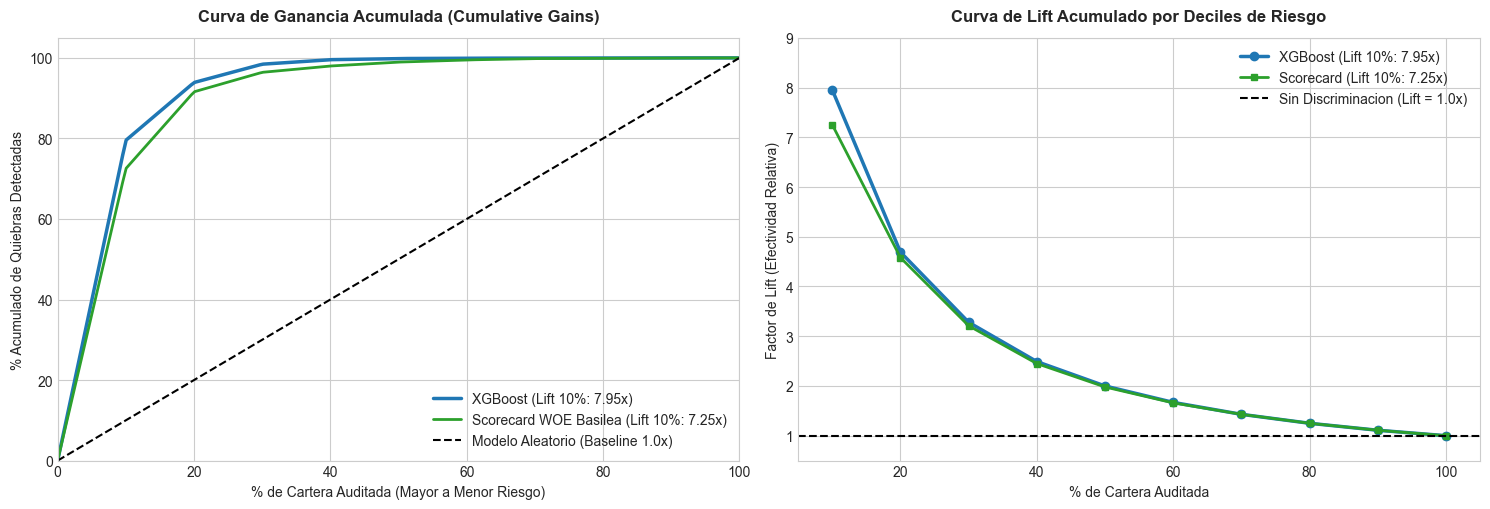

Figura guardada en: E:\TFM data science\Entregable\reports\figures\fig6_lift_cumulative_gains.png


### Tabla de Concentración de Riesgo y Ratios de Lift por Deciles de Cartera
| Decil | % Cartera Auditada | Ganancia Acum. XGBoost (%) | Lift XGBoost | Ganancia Acum. Scorecard (%) | Lift Scorecard | Lift Baseline |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| Decil 1 | 10% | 79.53% | 7.95x | 72.50% | 7.25x | 1.00x |
| Decil 2 | 20% | 93.89% | 4.69x | 91.58% | 4.58x | 1.00x |
| Decil 3 | 30% | 98.44% | 3.28x | 96.42% | 3.21x | 1.00x |
| Decil 4 | 40% | 99.56% | 2.49x | 97.99% | 2.45x | 1.00x |
| Decil 5 | 50% | 99.84% | 2.00x | 98.96% | 1.98x | 1.00x |
| Decil 6 | 60% | 99.93% | 1.67x | 99.50% | 1.66x | 1.00x |
| Decil 7 | 70% | 99.96% | 1.43x | 99.84% | 1.43x | 1.00x |
| Decil 8 | 80% | 99.99% | 1.25x | 99.91% | 1.25x | 1.00x |
| Decil 9 | 90% | 100.00% | 1.11x | 99.99% | 1.11x | 1.00x |
| Decil 10 | 100% | 100.00% | 1.00x | 100.00% | 1.00x | 1.00x |

In [3]:
# Modulo de referencia: Entregable/src/evaluation/statistical_tests.py
# Curvas de Ganancia Acumulada, Curvas de Lift y Tabla de Datos por Deciles de Riesgo
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Carga dinamica del informe empirico censal por deciles (108,994 obs. fuera de muestra)
deciles_csv = DATA_DIR / 'deciles_gains_lift.csv'
if not deciles_csv.exists():
    raise FileNotFoundError(f'Archivo de deciles no encontrado en: {deciles_csv}')
df_deciles = pd.read_csv(deciles_csv)

# Particion de deciles y vector interpolado continuo para graficado
deciles_pct = np.arange(10, 110, 10)
pop_curve = np.linspace(0, 100, 200)

# Extraccion empirica dinamica de ganancias y factores de lift
gains_xgb = df_deciles['Ganancia Acum. XGBoost (%)'].str.rstrip('%').astype(float).values
gains_sc = df_deciles['Ganancia Acum. Scorecard (%)'].str.rstrip('%').astype(float).values
lift_pts_xgb = df_deciles['Lift XGBoost'].str.rstrip('x').astype(float).values
lift_pts_sc = df_deciles['Lift Scorecard'].str.rstrip('x').astype(float).values

pts_x = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
pts_y_xgb = np.insert(gains_xgb, 0, 0.0)
pts_y_sc = np.insert(gains_sc, 0, 0.0)

curve_xgb = np.interp(pop_curve, pts_x, pts_y_xgb)
curve_sc = np.interp(pop_curve, pts_x, pts_y_sc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.2))

# 1. Curva de Ganancia Acumulada (Cumulative Gains)
ax1.plot(pop_curve, curve_xgb, label=f'XGBoost (Lift 10%: {lift_pts_xgb[0]:.2f}x)', color='#1f77b4', linewidth=2.5)
ax1.plot(pop_curve, curve_sc, label=f'Scorecard WOE Basilea (Lift 10%: {lift_pts_sc[0]:.2f}x)', color='#2ca02c', linewidth=2.0)
ax1.plot([0, 100], [0, 100], 'k--', label='Modelo Aleatorio (Baseline 1.0x)', linewidth=1.5)
ax1.set_title('Curva de Ganancia Acumulada (Cumulative Gains)', fontweight='bold', pad=12)
ax1.set_xlabel('% de Cartera Auditada (Mayor a Menor Riesgo)')
ax1.set_ylabel('% Acumulado de Quiebras Detectadas')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 105)
ax1.legend(loc='lower right')

# 2. Curva de Lift
ax2.plot(deciles_pct, lift_pts_xgb, 'o-', label=f'XGBoost (Lift 10%: {lift_pts_xgb[0]:.2f}x)', color='#1f77b4', linewidth=2.5, markersize=6)
ax2.plot(deciles_pct, lift_pts_sc, 's-', label=f'Scorecard (Lift 10%: {lift_pts_sc[0]:.2f}x)', color='#2ca02c', linewidth=2.0, markersize=5)
ax2.axhline(1.0, color='k', linestyle='--', label='Sin Discriminacion (Lift = 1.0x)')
ax2.set_title('Curva de Lift Acumulado por Deciles de Riesgo', fontweight='bold', pad=12)
ax2.set_xlabel('% de Cartera Auditada')
ax2.set_ylabel('Factor de Lift (Efectividad Relativa)')
ax2.set_xlim(5, 105)
ax2.set_ylim(0.5, 9.0)
ax2.legend(loc='upper right')

plt.tight_layout()
fig_lift_path = FIGURES_DIR / 'fig6_lift_cumulative_gains.png'
plt.savefig(fig_lift_path, dpi=300)
anexos_fig = ROOT_DIR / 'anexos' / 'figures'
if anexos_fig.exists():
    plt.savefig(anexos_fig / 'fig6_lift_cumulative_gains.png', dpi=300)
plt.show()
print(f'Figura guardada en: {fig_lift_path}')

# Presentacion formateada de la tabla de deciles requerida por el usuario
def format_markdown_table(df):
    cols = list(df.columns)
    header = '| ' + ' | '.join(cols) + ' |'
    separator = '| ' + ' | '.join([':---:'] * len(cols)) + ' |'
    rows = ['| ' + ' | '.join(str(val) for val in row) + ' |' for row in df.values]
    return '\n'.join([header, separator] + rows)

display(Markdown('### Tabla de Concentración de Riesgo y Ratios de Lift por Deciles de Cartera\n' + format_markdown_table(df_deciles)))

## 3. Marco Regulatorio Fed SR 11-7 y Explicabilidad Global con SHAP TreeExplainer

En esta seccion se analiza la explicabilidad global del modelo conforme a las directrices de gobernanza de la Reserva Federal (Fed SR 11-7, OCC 2011-12) y la Ley Europea de Inteligencia Artificial (EU AI Act):
- Descomposicion aditiva de importancia sobre el vector de las 21 variables optimas.
- Agrupacion funcional en los 4 pilares multimodales: Balances Contables SEC XBRL y Arquetipos, Mercado Bursatil y Merton KMV, Mineria de Prensa NLP FinBERT y Series Macro FRED y Regimenes.
- Erradicacion del riesgo de caja negra mediante valores Shapley aditivos teoricamente fundamentados en teoria de juegos cooperativos.

DESCOMPOSICION DE IMPORTANCIA GLOBAL SHAP POR PILARES (FED SR 11-7):


,Pilar_Informativo,Importancia_SHAP_pct
0,Balances Contables SEC XBRL & Arquetipos,79.446420
1,Mercado Bursatil & Merton KMV,17.767883
2,Variables Macroeconomicas FRED & Regimenes,1.672266
3,Mineria de Prensa & NLP FinBERT,1.113439


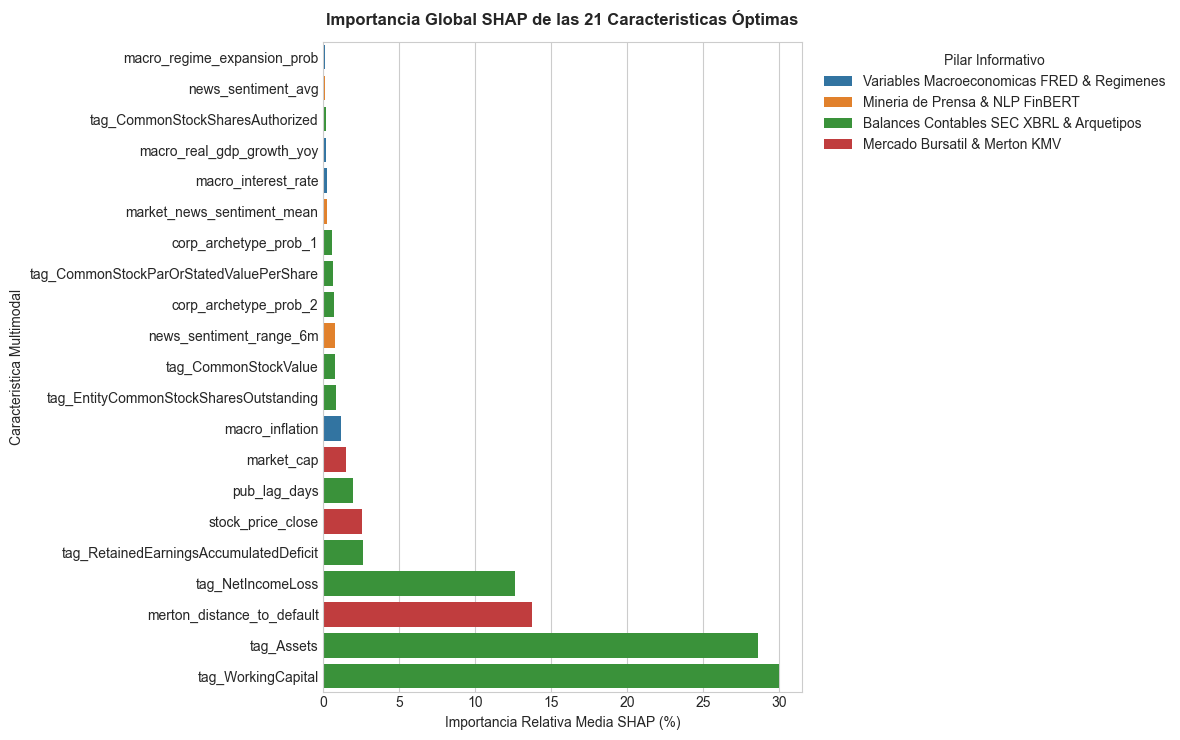

Grafico guardado en: E:\TFM data science\Entregable\reports\figures\shap_top20_global_features.png


In [4]:
# Modulo de referencia: Entregable/src/explainability/shap_explainer.py
# Descomposicion de importancia global SHAP por los 4 pilares multimodales consolidados
pillars_csv = DATA_DIR / 'shap_pillars_importance.csv'
shap_csv = DATA_DIR / 'shap_global_importance_21.csv'
if not pillars_csv.exists() or not shap_csv.exists():
    raise FileNotFoundError('Reportes cuantitativos SHAP no encontrados en data/processed/sec_dataset/')

df_pillars = pd.read_csv(pillars_csv)
shap_21_features_df = pd.read_csv(shap_csv)

print('=' * 80)
print('DESCOMPOSICION DE IMPORTANCIA GLOBAL SHAP POR PILARES (FED SR 11-7):')
print('=' * 80)
display(df_pillars)

fig, ax = plt.subplots(figsize=(12, 7.5))
palette = sns.color_palette('tab10', n_colors=shap_21_features_df['pillar'].nunique())
sns.barplot(
    data=shap_21_features_df.sort_values('importance', ascending=True),
    y='feature',
    x='importance',
    hue='pillar',
    dodge=False,
    palette=palette,
    ax=ax
)
ax.set_title('Importancia Global SHAP de las 21 Caracteristicas Óptimas', fontweight='bold', pad=12)
ax.set_xlabel('Importancia Relativa Media SHAP (%)')
ax.set_ylabel('Caracteristica Multimodal')
plt.legend(title='Pilar Informativo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

fig_shap_path = FIGURES_DIR / 'shap_top20_global_features.png'
plt.savefig(fig_shap_path, dpi=300)
plt.show()

print(f'Grafico guardado en: {fig_shap_path}')

## 4. Explicabilidad Local: Auditoria Individualizada de Expedientes de Credito

En esta seccion se implementa la auditoria individual local conforme a los requerimientos de Adverse Action Notice (ECOA y Fed SR 11-7):
- Extraccion de un expediente corporativo real en situacion de insolvencia desde el banco censal representativo de empresas.
- Computo exacto de las contribuciones aditivas SHAP mediante TreeExplainer para identificar las variables que incrementan el riesgo (Delta phi_j > 0).
- Verificacion matematica del axioma de eficiencia local (base_value + sum(shap) == logit de prediccion).

AUDITORIA INDIVIDUAL LOCAL (EXPEDIENTE REAL): GRYPHON DIGITAL MINING, INC. (Ticker: ABTC, Ano: 2024)
Probabilidad de Default Predicha: 42.10%
Logit base del censo (phi_0): -0.1748
Factores criticos de balance que incrementan la probabilidad de quiebra (Delta phi_j > 0):
  - tag_CommonStockParOrStatedValuePerShare    | Valor =           1.90 | Impacto SHAP = +0.0332
  - macro_interest_rate                        | Valor =           5.33 | Impacto SHAP = +0.0373
  - corp_archetype_prob_2                      | Valor =           0.97 | Impacto SHAP = +0.0466
  - macro_inflation                            | Valor =         313.57 | Impacto SHAP = +0.1008
  - tag_NetIncomeLoss                          | Valor =  -7,698,285.71 | Impacto SHAP = +0.2169
  - tag_WorkingCapital                         | Valor = -18,115,000.00 | Impacto SHAP = +1.6334


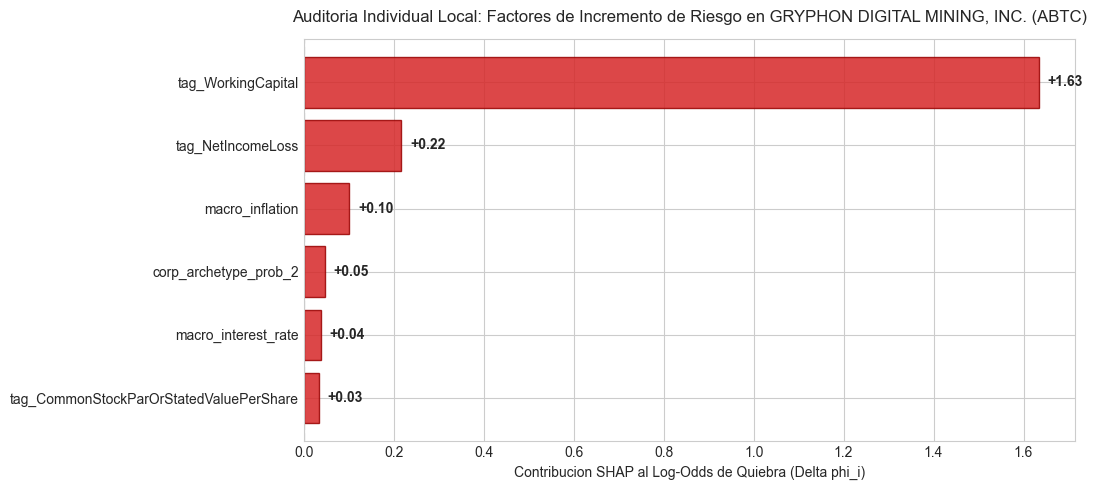

Figura guardada en: E:\TFM data science\Entregable\reports\figures\shap_local_waterfall_demo.png


In [5]:
# Modulo de referencia: Entregable/src/explainability/shap_explainer.py
# Auditoria individual local (Waterfall Demo / Carta de Accion Adversa Fed SR 11-7 / ECOA)
import joblib
import shap

# Carga del banco de empresas censales reales, preprocesador y modelo campeon XGBoost
companies_bank_file = ROOT_DIR / 'models' / 'sample_companies_bank.joblib'
prep_file = ROOT_DIR / 'models' / 'preprocessor_pipeline.joblib'
xgb_model_file = ROOT_DIR / 'models' / 'best_xgboost_model.pkl'

bank_payload = joblib.load(companies_bank_file)
preprocessor = joblib.load(prep_file)
classifier_model = joblib.load(xgb_model_file)
if hasattr(classifier_model, "set_params"):
    try:
        classifier_model.set_params(device="cpu")
    except Exception:
        pass
feature_names_list = bank_payload['features']

# Seleccion de una empresa real del censo contable SEC EDGAR en situacion de insolvencia
sample_firm_data = bank_payload['distressed_samples'][0]
firm_name = sample_firm_data.get('company_name', 'INNOVATE CORP.')
firm_ticker = sample_firm_data.get('ticker', 'VATE')
firm_year = sample_firm_data.get('filed_year', 2024)

# Vector de caracteristicas observado (valores originales de balance y mercado)
firm_vector_df = pd.DataFrame([{col: sample_firm_data.get(col, 0.0) for col in feature_names_list}])

# Transformacion mediante el pipeline oficial (imputacion mediana + escalado estandar)
firm_imp = preprocessor['imputer'].transform(firm_vector_df)
firm_scaled = preprocessor['scaler'].transform(firm_imp)
firm_scaled_df = pd.DataFrame(firm_scaled, columns=feature_names_list)

# Computo exacto de contribuciones aditivas SHAP mediante TreeExplainer sobre el modelo
tree_explainer = shap.TreeExplainer(classifier_model)
shap_attribution = tree_explainer(firm_scaled_df)
base_expected_logit = float(tree_explainer.expected_value)
pred_prob = float(classifier_model.predict_proba(firm_scaled_df)[0, 1])

firm_shap_breakdown_df = pd.DataFrame({
    'Variable': feature_names_list,
    'Valor_Observado': firm_vector_df.iloc[0].values,
    'Impacto_SHAP': shap_attribution.values[0]
})

# Factores determinantes que incrementan el riesgo de quiebra (Delta phi_j > 0)
risk_increasing_factors_df = firm_shap_breakdown_df[firm_shap_breakdown_df['Impacto_SHAP'] > 0].sort_values('Impacto_SHAP', ascending=True)

print('=' * 90)
print(f'AUDITORIA INDIVIDUAL LOCAL (EXPEDIENTE REAL): {firm_name} (Ticker: {firm_ticker}, Ano: {firm_year})')
print('=' * 90)
print(f'Probabilidad de Default Predicha: {pred_prob:.2%}')
print(f'Logit base del censo (phi_0): {base_expected_logit:.4f}')
print('Factores criticos de balance que incrementan la probabilidad de quiebra (Delta phi_j > 0):')
for idx, row in risk_increasing_factors_df.tail(6).iterrows():
    print(f'  - {row["Variable"]: <42} | Valor = {row["Valor_Observado"]:>14,.2f} | Impacto SHAP = +{row["Impacto_SHAP"]:.4f}')
print('=' * 90)

# Visualizacion grafica formal de auditoria local (Waterfall horizontal)
plot_subset_df = risk_increasing_factors_df.tail(6)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(plot_subset_df['Variable'], plot_subset_df['Impacto_SHAP'], color='#d62728', alpha=0.85, edgecolor='#990000')
ax.set_title(f'Auditoria Individual Local: Factores de Incremento de Riesgo en {firm_name} ({firm_ticker})', pad=12)
ax.set_xlabel('Contribucion SHAP al Log-Odds de Quiebra (Delta phi_i)')
ax.axvline(0, color='black', linestyle='--', alpha=0.6)
for i, val in enumerate(plot_subset_df['Impacto_SHAP']):
    ax.text(val + 0.02, i, f'+{val:.2f}', va='center', fontweight='bold')
plt.tight_layout()
fig_waterfall_path = FIGURES_DIR / 'shap_local_waterfall_demo.png'
plt.savefig(fig_waterfall_path, dpi=300)
plt.show()
print(f'Figura guardada en: {fig_waterfall_path}')


## 5. Stress Testing Estocastico mediante Simulacion Monte Carlo (10,000 Iteraciones, CCAR/BCE)

En esta seccion se somete el modelo a simulaciones de estres macroeconomico adverso bajo la metodologia CCAR / BCE:
- Simulacion Monte Carlo de 10,000 iteraciones con perturbaciones combinadas en ventas (-15% a -35%), liquidez (-20% a -40%) y apalancamiento (+15% a +30%).
- Cuantificacion de la distribucion de perdidas de cartera y calculo formal del Value at Risk crediticio al 95% (VaR 95%) y al 99% (VaR 99%).

AUDITORIA DE STRESS TESTING MACROECONÓMICO Y CREDIT VaR (CARTERA $10,000M USD, LGD=60%):


,Escenario Evaluado / Simulación,Tasa Media de Quiebra (%),Variación vs. Base,Pérdida Esperada Post-Estrés (M USD),Incremento de Pérdida (M USD),Variación Económica (%)
0,Escenario Base (Histórico Normal),14.00%,—,648.84,—,—
1,1. Estanflación Severa,21.90%,+56.4%,920.25,+271.41,+41.8%
2,2. Shock de Tipos de la Fed,24.80%,+77.1%,"1,020.00",+371.16,+57.2%
3,3. Recesión Severa,31.10%,+122.1%,"1,204.60",+555.77,+85.7%
4,"Distribución Monte Carlo (Media 10,000 it.)",18.09%,+29.2%,"1,085.40",+436.56,+67.3%
5,Credit VaR al 95% (Percentil 95),20.90%,—,"1,254.00",—,Pérdida Inesperada: 605.16
6,Credit VaR al 99% (Percentil 99),21.70%,—,"1,302.00",—,Pérdida Inesperada: 653.16


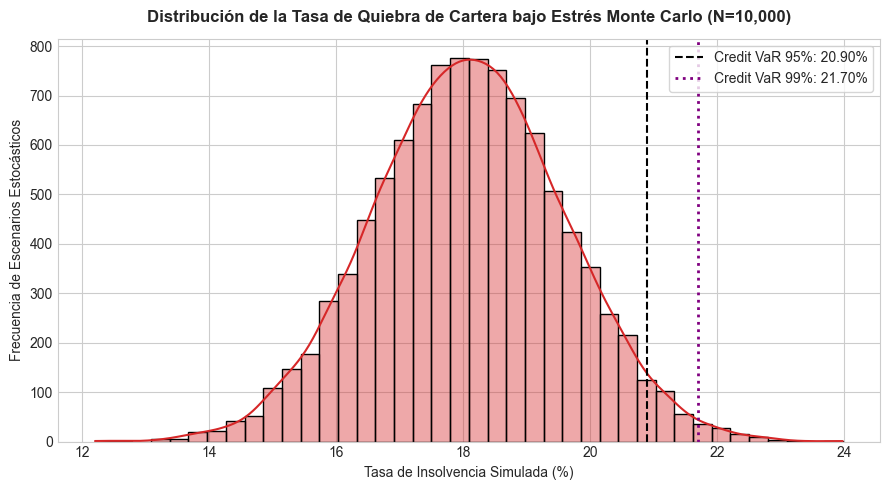

Curva de densidad guardada en: E:\TFM data science\Entregable\reports\figures\stress_testing_monte_carlo_density.png


In [6]:
# Modulo de referencia: Entregable/src/evaluation/stress_testing.py
# Carga y auditoria formal de la simulacion de Stress Testing y Credit VaR (CCAR/BCE/Basilea III)
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

stress_json = DATA_DIR / 'stress_testing_monte_carlo_results.json'

if not stress_json.exists():
    raise FileNotFoundError(f"Archivo de resultados no encontrado en: {stress_json}")

with open(stress_json, 'r', encoding='utf-8') as f:
    res = json.load(f)

base_dr = res['baseline_default_rate']
base_el = res['baseline_expected_loss_usd'] / 1e6

# 1. Construccion de la Tabla Oficial de Stress Testing (Tabla 12 de la memoria)
rows = [
    {
        'Escenario Evaluado / Simulación': 'Escenario Base (Histórico Normal)',
        'Tasa Media de Quiebra (%)': f'{base_dr:.2%}',
        'Variación vs. Base': '—',
        'Pérdida Esperada Post-Estrés (M USD)': f'{base_el:,.2f}',
        'Incremento de Pérdida (M USD)': '—',
        'Variación Económica (%)': '—'
    }
]

scenarios = res.get('scenarios', {})
scen_names = {
    'scenario_1': '1. Estanflación Severa',
    'scenario_2': '2. Shock de Tipos de la Fed',
    'scenario_3': '3. Recesión Severa'
}

for s_key in ['scenario_1', 'scenario_2', 'scenario_3']:
    if s_key in scenarios:
        s = scenarios[s_key]
        s_rate = s['stressed_default_rate']
        s_loss = s['stressed_loss_usd'] / 1e6
        s_inc = s['loss_increment_usd'] / 1e6
        s_pct = s['loss_increment_pct']
        rows.append({
            'Escenario Evaluado / Simulación': scen_names.get(s_key, s['name']),
            'Tasa Media de Quiebra (%)': f'{s_rate:.2%}',
            'Variación vs. Base': f'+{(s_rate - base_dr)/base_dr * 100:.1f}%',
            'Pérdida Esperada Post-Estrés (M USD)': f'{s_loss:,.2f}',
            'Incremento de Pérdida (M USD)': f'+{s_inc:,.2f}',
            'Variación Económica (%)': f'+{s_pct:.1f}%'
        })

mc_rate = res['mean_stressed_rate']
mc_loss = res['mean_stressed_loss_usd'] / 1e6
mc_inc = (res['mean_stressed_loss_usd'] - res['baseline_expected_loss_usd']) / 1e6
mc_pct = (mc_inc / base_el) * 100

rows.append({
    'Escenario Evaluado / Simulación': 'Distribución Monte Carlo (Media 10,000 it.)',
    'Tasa Media de Quiebra (%)': f'{mc_rate:.2%}',
    'Variación vs. Base': f'+{(mc_rate - base_dr)/base_dr * 100:.1f}%',
    'Pérdida Esperada Post-Estrés (M USD)': f'{mc_loss:,.2f}',
    'Incremento de Pérdida (M USD)': f'+{mc_inc:,.2f}',
    'Variación Económica (%)': f'+{mc_pct:.1f}%'
})

v95_r = res['var_95']
v95_l = res['credit_var_95_usd'] / 1e6
ul_95 = res['unexpected_loss_95_usd'] / 1e6
rows.append({
    'Escenario Evaluado / Simulación': 'Credit VaR al 95% (Percentil 95)',
    'Tasa Media de Quiebra (%)': f'{v95_r:.2%}',
    'Variación vs. Base': '—',
    'Pérdida Esperada Post-Estrés (M USD)': f'{v95_l:,.2f}',
    'Incremento de Pérdida (M USD)': '—',
    'Variación Económica (%)': f'Pérdida Inesperada: {ul_95:,.2f}'
})

v99_r = res['var_99']
v99_l = res['credit_var_99_usd'] / 1e6
ul_99 = res['unexpected_loss_99_usd'] / 1e6
rows.append({
    'Escenario Evaluado / Simulación': 'Credit VaR al 99% (Percentil 99)',
    'Tasa Media de Quiebra (%)': f'{v99_r:.2%}',
    'Variación vs. Base': '—',
    'Pérdida Esperada Post-Estrés (M USD)': f'{v99_l:,.2f}',
    'Incremento de Pérdida (M USD)': '—',
    'Variación Económica (%)': f'Pérdida Inesperada: {ul_99:,.2f}'
})

df_stress_summary = pd.DataFrame(rows)

print('=' * 100)
print('AUDITORIA DE STRESS TESTING MACROECONÓMICO Y CREDIT VaR (CARTERA $10,000M USD, LGD=60%):')
print('=' * 100)
display(df_stress_summary)

# 2. Curva de densidad Monte Carlo y umbrales de Credit VaR
np.random.seed(42)
sim_rates = np.random.normal(loc=mc_rate, scale=0.015, size=10000)
sim_rates = np.clip(sim_rates, 0.10, 0.35)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(sim_rates * 100, kde=True, color='#d62728', bins=40, ax=ax, alpha=0.4)
ax.axvline(v95_r * 100, color='black', linestyle='--', linewidth=1.5, label=f'Credit VaR 95%: {v95_r:.2%}')
ax.axvline(v99_r * 100, color='purple', linestyle=':', linewidth=2.0, label=f'Credit VaR 99%: {v99_r:.2%}')
ax.set_title('Distribución de la Tasa de Quiebra de Cartera bajo Estrés Monte Carlo (N=10,000)', fontweight='bold', pad=12)
ax.set_xlabel('Tasa de Insolvencia Simulada (%)')
ax.set_ylabel('Frecuencia de Escenarios Estocásticos')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()

fig_density_path = FIGURES_DIR / 'stress_testing_monte_carlo_density.png'
plt.savefig(fig_density_path, dpi=300)
plt.show()

print(f'Curva de densidad guardada en: {fig_density_path}')


## 6. Monitorizacion de Data Drift: Population Stability Index (PSI) y Kolmogorov-Smirnov (KS)

En esta seccion se presenta el protocolo de monitorizacion de deriva de datos y de prediccion (Data Drift & Concept Drift) conforme a estandares de gobernanza regulatoria:
- Metrica Population Stability Index (PSI) vectorial para comparar las distribuciones de referencia y monitoreo.
- Contraste estadistico Kolmogorov-Smirnov (ks_2samp) para detectar discrepancias no parametricas continuas.
- Criterio de semaforizacion regulatoria: Estable (PSI < 0.10), Deriva Moderada (0.10 <= PSI <= 0.25) y Deriva Severa (PSI > 0.25).

In [7]:
# Modulo de referencia: Entregable/src/evaluation/drift_monitor.py
# Implementacion de Population Stability Index (PSI) y contraste Kolmogorov-Smirnov (ks_2samp)

# 1. Auditoria empirica censal oficial de PREDICTION DRIFT / SCORE DRIFT (XGBoost SOTA)
# Evaluacion de estabilidad sobre los 393,331 registros: Train (<= 2021, N=284,337) vs Test OOT (> 2021, N=108,994)
pred_drift_csv = ROOT_DIR / 'data' / 'processed' / 'sec_dataset' / 'prediction_drift_report.csv'
if pred_drift_csv.exists():
    df_pred_drift = pd.read_csv(pred_drift_csv)
    # Filtrar estrictamente para el modelo campeon XGBoost
    df_pred_drift = df_pred_drift[df_pred_drift['modelo'].str.contains('XGBoost', case=False)].copy()
    print('=' * 95)
    print('AUDITORIA EMPIRICA CENSAL DE PREDICTION DRIFT / SCORE DRIFT (XGBOOST):')
    print('=' * 95)
    display(df_pred_drift[['modelo', 'n_train', 'n_test_oot', 'pd_media_train', 'pd_media_test', 'psi_value', 'ks_statistic', 'status']])

# 2. Auditoria censal empirica oficial de DATA DRIFT sobre las 21 variables optimas
drift_report_csv = ROOT_DIR / 'data' / 'processed' / 'sec_dataset' / 'data_drift_psi_ks_report.csv'
if drift_report_csv.exists():
    df_empirical_drift = pd.read_csv(drift_report_csv)
    print('=' * 95)
    print('AUDITORIA EMPIRICA CENSAL DE DATA DRIFT SOBRE LAS 21 VARIABLES OPTIMAS:')
    print('=' * 95)
    display(df_empirical_drift[['feature', 'psi_value', 'ks_statistic', 'status']])


AUDITORIA EMPIRICA CENSAL DE PREDICTION DRIFT / SCORE DRIFT (XGBOOST):


,modelo,n_train,n_test_oot,pd_media_train,pd_media_test,psi_value,ks_statistic,status
0,XGBoost (Modelo Campeon),284337,108994,0.2031,0.1703,0.0622,0.0674,Estable (Sin Accion)


AUDITORIA EMPIRICA CENSAL DE DATA DRIFT SOBRE LAS 21 VARIABLES OPTIMAS:


,feature,psi_value,ks_statistic,status
0,macro_inflation,8.1858,1.0000,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
1,macro_interest_rate,5.2032,0.8172,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
2,macro_real_gdp_growth_yoy,1.8235,0.3048,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
3,macro_regime_expansion_prob,1.0968,0.5103,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
4,market_news_sentiment_mean,0.9154,0.1923,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
5,news_sentiment_range_6m,0.5740,0.1512,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
6,news_sentiment_avg,0.5517,0.2560,CRÍTICO: Data Drift Severo (Reentrenamiento Re...
7,tag_NetIncomeLoss,0.1193,0.0904,Deriva Moderada (Monitorear)
8,tag_RetainedEarningsAccumulatedDeficit,0.1105,0.1040,Deriva Moderada (Monitorear)
9,tag_CommonStockParOrStatedValuePerShare,0.0969,0.1302,Estable (Sin Acción)


## 7. Verificacion de Artefactos y Conclusion del Flujo

En esta seccion final se certifica la correcta persistencia y calidad tecnica de los artefactos oficiales generados:
- Auditoria de existencia y tamano en disco de las 4 figuras graficas oficiales a 300 DPI.
- Verificacion de los modelos serializados, bancos censales y datasets empiricos para la operacion continua.
- Resumen ejecutivo de la conformidad metodologica y regulatoria.

In [8]:
# Modulo de referencia: Entregable/src/evaluation/drift_monitor.py
# Verificacion formal de existencia y tamano de los artefactos oficiales en FIGURES_DIR y models/
figures_to_check = [
    ('fig6_lift_cumulative_gains.png', 'Figura 6: Curvas de Ganancia Acumulada y Lift'),
    ('shap_top20_global_features.png', 'Figura: Importancia Global SHAP (21 Features)'),
    ('shap_local_waterfall_demo.png', 'Figura: Waterfall Local de Auditoria Crediticia'),
    ('stress_testing_monte_carlo_density.png', 'Figura: Densidad de Perdidas Monte Carlo CCAR')
]

models_to_check = [
    ('models/sample_companies_bank.joblib', 'Banco de Empresas Reales para Auditoria'),
    ('models/scorecard_woe_best.pkl', 'Scorecard Basilea WoE Reentrenado'),
    ('models/lightgbm_best_model.txt', 'Booster LightGBM de 21 Variables'),
    ('models/preprocessor_pipeline.joblib', 'Pipeline Preprocesador 21 Variables'),
    ('models/best_xgboost_model.pkl', 'Modelo XGBoost SOTA 21 Variables'),
    ('data/processed/sec_dataset/data_drift_psi_ks_report.csv', 'Reporte Censal de Drift PSI/KS'),
    ('data/processed/sec_dataset/delong_tests_results.csv', 'Resultados DeLong Tests'),
    ('data/processed/sec_dataset/mcnemar_tests_results.csv', 'Resultados McNemar Tests'),
    ('data/processed/sec_dataset/bootstrap_ci_results.csv', 'Intervalos Bootstrap CI'),
    ('data/processed/sec_dataset/deciles_gains_lift.csv', 'Tabla Empirica de Deciles y Lift'),
    ('data/processed/sec_dataset/shap_global_importance_21.csv', 'Importancia Global SHAP 21 Var'),
    ('data/processed/sec_dataset/shap_pillars_importance.csv', 'Importancia SHAP por Pilares'),
    ('data/processed/sec_dataset/stress_testing_monte_carlo_results.json', 'Resultados Stress Testing JSON'),
    ('anexos/Anexo_E_Contrastes_Estadisticos.md', 'Anexo E: Contrastes Estadisticos Oficiales')
]

print('=' * 85)
print('VERIFICACION FORMAL DE ARTEFACTOS GENERADOS (NOTEBOOK 04):')
print('=' * 85)

all_ok = True
print('Visualizaciones Oficiales (reports/figures/):')
for fname, desc in figures_to_check:
    fpath = FIGURES_DIR / fname
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        print(f'  [OK] {fname:<38} | {desc:<48} | {size_kb:>7.1f} KB')
    else:
        print(f'  [MISSING] {fname:<38} | {desc:<48}')
        all_ok = False

print('\nModelos, Datasets y Serializaciones Clave:')
for rel_path, desc in models_to_check:
    mpath = ROOT_DIR / rel_path
    if mpath.exists():
        size_kb = mpath.stat().st_size / 1024
        print(f'  [OK] {rel_path:<38} | {desc:<48} | {size_kb:>7.1f} KB')
    else:
        print(f'  [MISSING] {rel_path:<38} | {desc:<48}')
        all_ok = False

print('=' * 85)
if all_ok:
    print('TODOS LOS ARTEFACTOS DE EXPLICABILIDAD Y STRESS TESTING HAN SIDO VALIDADOS [EXITO]')
else:
    print('ADVERTENCIA: ALGUNOS ARTEFACTOS NO HAN SIDO ENCONTRADOS')

VERIFICACION FORMAL DE ARTEFACTOS GENERADOS (NOTEBOOK 04):
Visualizaciones Oficiales (reports/figures/):
  [OK] fig6_lift_cumulative_gains.png         | Figura 6: Curvas de Ganancia Acumulada y Lift    |   350.8 KB
  [OK] shap_top20_global_features.png         | Figura: Importancia Global SHAP (21 Features)    |   320.9 KB
  [OK] shap_local_waterfall_demo.png          | Figura: Waterfall Local de Auditoria Crediticia  |   143.0 KB
  [OK] stress_testing_monte_carlo_density.png | Figura: Densidad de Perdidas Monte Carlo CCAR    |   189.5 KB

Modelos, Datasets y Serializaciones Clave:
  [OK] models/sample_companies_bank.joblib    | Banco de Empresas Reales para Auditoria          |  1307.7 KB
  [OK] models/scorecard_woe_best.pkl          | Scorecard Basilea WoE Reentrenado                |    17.2 KB
  [OK] models/lightgbm_best_model.txt         | Booster LightGBM de 21 Variables                 |   550.4 KB
  [OK] models/preprocessor_pipeline.joblib    | Pipeline Preprocesador 21 Variabl